#### 1. Thư viện

In [39]:
import pandas as pd
import numpy as np
from scipy.linalg import inv
from scipy.linalg import eig
from scipy.stats import f
import matplotlib.patches as patches
import matplotlib.pyplot as plt

#### 2. Tải dữ liệu và tiền xử lý dữ liệu

In [40]:
# Tải tập dữ liệu Swiss Bank Notes ---
try:
    print("Đang tải dữ liệu Swiss Bank Notes...")
    df = pd.read_csv("Sample-Data-Swiss-Bank-Notes.csv")

    print("Cấu trúc dữ liệu:")
    print(df.info())

except FileNotFoundError:
    print("Lỗi: Không tìm thấy tệp!!!")
    exit()



Đang tải dữ liệu Swiss Bank Notes...
Cấu trúc dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Length               200 non-null    object
 1   Left                 200 non-null    object
 2   Right                200 non-null    object
 3   Bottom               200 non-null    object
 4   Top                  200 non-null    object
 5   Diagonal             200 non-null    object
 6   Genuine/Counterfeit  200 non-null    object
dtypes: object(7)
memory usage: 11.1+ KB
None


In [41]:
df

,Length,Left,Right,Bottom,Top,Diagonal,Genuine/Counterfeit
0,"Quantity[214.8, ""Millimeters""]","Quantity[131, ""Millimeters""]","Quantity[131.1, ""Millimeters""]","Quantity[9, ""Millimeters""]","Quantity[9.7, ""Millimeters""]","Quantity[141, ""Millimeters""]",counterfeit
1,"Quantity[214.6, ""Millimeters""]","Quantity[129.7, ""Millimeters""]","Quantity[129.7, ""Millimeters""]","Quantity[8.1, ""Millimeters""]","Quantity[9.5, ""Millimeters""]","Quantity[141.7, ""Millimeters""]",counterfeit
2,"Quantity[214.8, ""Millimeters""]","Quantity[129.7, ""Millimeters""]","Quantity[129.7, ""Millimeters""]","Quantity[8.7, ""Millimeters""]","Quantity[9.6, ""Millimeters""]","Quantity[142.2, ""Millimeters""]",counterfeit
3,"Quantity[214.8, ""Millimeters""]","Quantity[129.7, ""Millimeters""]","Quantity[129.6, ""Millimeters""]","Quantity[7.5, ""Millimeters""]","Quantity[10.4, ""Millimeters""]","Quantity[142, ""Millimeters""]",counterfeit
4,"Quantity[215, ""Millimeters""]","Quantity[129.6, ""Millimeters""]","Quantity[129.7, ""Millimeters""]","Quantity[10.4, ""Millimeters""]","Quantity[7.7, ""Millimeters""]","Quantity[141.8, ""Millimeters""]",counterfeit
...,...,...,...,...,...,...,...
195,"Quantity[215, ""Millimeters""]","Quantity[130.4, ""Millimeters""]","Quantity[130.3, ""Millimeters""]","Quantity[9.9, ""Millimeters""]","Quantity[12.1, ""Millimeters""]","Quantity[139.6, ""Millimeters""]",genuine
196,"Quantity[215.1, ""Millimeters""]","Quantity[130.3, ""Millimeters""]","Quantity[129.9, ""Millimeters""]","Quantity[10.3, ""Millimeters""]","Quantity[11.5, ""Millimeters""]","Quantity[139.7, ""Millimeters""]",genuine
197,"Quantity[214.8, ""Millimeters""]","Quantity[130.3, ""Millimeters""]","Quantity[130.4, ""Millimeters""]","Quantity[10.6, ""Millimeters""]","Quantity[11.1, ""Millimeters""]","Quantity[140, ""Millimeters""]",genuine
198,"Quantity[214.7, ""Millimeters""]","Quantity[130.7, ""Millimeters""]","Quantity[130.8, ""Millimeters""]","Quantity[11.2, ""Millimeters""]","Quantity[11.2, ""Millimeters""]","Quantity[139.4, ""Millimeters""]",genuine


In [42]:
measurement_cols = ['Length', 'Left', 'Right', 'Bottom', 'Top', 'Diagonal']

#Mã hóa tất cả dữ liệu đầu vào đưa về theo kiểu số thực
for col in measurement_cols:
    df[col] = df[col].astype(str).str.extract(r'Quantity\[(\d+\.?\d*),')[0].astype(float)


In [43]:
df

,Length,Left,Right,Bottom,Top,Diagonal,Genuine/Counterfeit
0,214.8,131.0,131.1,9.0,9.7,141.0,counterfeit
1,214.6,129.7,129.7,8.1,9.5,141.7,counterfeit
2,214.8,129.7,129.7,8.7,9.6,142.2,counterfeit
3,214.8,129.7,129.6,7.5,10.4,142.0,counterfeit
4,215.0,129.6,129.7,10.4,7.7,141.8,counterfeit
...,...,...,...,...,...,...,...
195,215.0,130.4,130.3,9.9,12.1,139.6,genuine
196,215.1,130.3,129.9,10.3,11.5,139.7,genuine
197,214.8,130.3,130.4,10.6,11.1,140.0,genuine
198,214.7,130.7,130.8,11.2,11.2,139.4,genuine


In [44]:
# Tách dữ liệu theo nhóm và loại bỏ các NaN còn sót
genuine_df = df[df['Genuine/Counterfeit'] == 'genuine'][measurement_cols].dropna()  #Tiền thật
counterfeit_df = df[df['Genuine/Counterfeit'] == 'counterfeit'][measurement_cols].dropna() #Tiền giả

# Lấy các ma trận numpy từ DataFrame đã làm sạch và loại bỏ NaN
X1 = genuine_df.values
X2 = counterfeit_df.values

# Lấy các ma trận numpy từ DataFrame
X1 = genuine_df.values
X2 = counterfeit_df.values

#### 3. Suy diễn trung bình của hai quần thể

##### 3.1. Tính các thành phần cho kiểm định Hotelling T^2



In [45]:
n1, p = X1.shape # n1 là cỡ mẫu nhóm 1, p là số biến
n2, _ = X2.shape # n2 là cỡ mẫu nhóm 2

- Trung bình mẫu

In [46]:
# Vecto trung bình mẫu cho từng nhóm
mean1 = np.mean(X1, axis=0)
mean2 = np.mean(X2, axis=0)
print("Mean 1:", mean1)
print("Mean 2:", mean2)

Mean 1: [214.823 130.3   130.193  10.53   11.133 139.45 ]
Mean 2: [214.969 129.943 129.72    8.305  10.168 141.517]


- Ma trận hiệp phương sai

In [47]:
# Ma trận hiệp phương sai mẫu
cov1 = np.cov(X1, rowvar=False) # rowvar=False vì mỗi hàng là một quan sát
cov2 = np.cov(X2, rowvar=False)
print("Covariance matrix 1:\n", cov1)
print("Covariance matrix 2:\n", cov2)

Covariance matrix 1:
 [[ 1.24011111e-01  3.15151515e-02  2.40010101e-02 -1.00595960e-01
   1.94353535e-02  1.15656566e-02]
 [ 3.15151515e-02  6.50505051e-02  4.67676768e-02 -2.40404040e-02
  -1.19191919e-02 -5.05050505e-03]
 [ 2.40010101e-02  4.67676768e-02  8.89404040e-02 -1.85757576e-02
   1.32323232e-04  3.41919192e-02]
 [-1.00595960e-01 -2.40404040e-02 -1.85757576e-02  1.28131313e+00
  -4.90191919e-01  2.38484848e-01]
 [ 1.94353535e-02 -1.19191919e-02  1.32323232e-04 -4.90191919e-01
   4.04455556e-01 -2.20707071e-02]
 [ 1.15656566e-02 -5.05050505e-03  3.41919192e-02  2.38484848e-01
  -2.20707071e-02  3.11212121e-01]]
Covariance matrix 2:
 [[ 1.50241414e-01  5.80131313e-02  5.72929293e-02  5.71262626e-02
   1.44525253e-02  5.48181818e-03]
 [ 5.80131313e-02  1.32576768e-01  8.58989899e-02  5.66515152e-02
   4.90666667e-02 -4.30616162e-02]
 [ 5.72929293e-02  8.58989899e-02  1.26262626e-01  5.81818182e-02
   3.06464646e-02 -2.37777778e-02]
 [ 5.71262626e-02  5.66515152e-02  5.81818182e

- Gộp ma trận hiệp phương sai của hai quần thể

In [48]:
# Ma trận hiệp phương sai gộp - Sp
# Công thức: Sp = ((n1-1)*Cov1 + (n2-1)*Cov2) / (n1+n2-2)
Sp = ((n1 - 1) * cov1 + (n2 - 1) * cov2) / (n1 + n2 - 2)
print("Pooled covariance matrix Sp:\n", Sp)

Pooled covariance matrix Sp:
 [[ 0.13712626  0.04476414  0.04064697 -0.02173485  0.01694394  0.00852374]
 [ 0.04476414  0.09881364  0.06633333  0.01630556  0.01857374 -0.02405606]
 [ 0.04064697  0.06633333  0.10760152  0.01980303  0.01538939  0.00520707]
 [-0.02173485  0.01630556  0.01980303  0.8472601  -0.37683333  0.11914899]
 [ 0.01694394  0.01857374  0.01538939 -0.37683333  0.41282172 -0.0486899 ]
 [ 0.00852374 -0.02405606  0.00520707  0.11914899 -0.0486899   0.25551061]]


##### 3.2. Thống kê Hotelling T^2

In [49]:
# Mghịch đảo của ma trận hiệp phương sai gộp
Sp_inv = inv(Sp)

# Hiệu của hai vecto trung bình
mean_diff = mean1 - mean2

# --- Tính toán thống kê Hotelling T^2 ---
# Công thức: T^2 = (n1*n2 / (n1+n2)) * (mean_diff' * Sp_inv * mean_diff)
T2_statistic = (n1 * n2 / (n1 + n2)) * (mean_diff.T @ Sp_inv @ mean_diff)

print(f"\nThống kê Hotelling T^2 : {T2_statistic:.4f}")


Thống kê Hotelling T^2 : 2412.4507


##### 3.3. Chuyển đổi sang thống kê F và tính P-value

In [50]:
# Công thức chuyển đổi T^2 sang F cho kiểm định hai mẫu:
# F = ((n1+n2-p-1) / (p*(n1+n2-2))) * T^2
F_statistic = ((n1 + n2 - p - 1) / (p * (n1 + n2 - 2))) * T2_statistic

# Bậc tự do cho phân phối F
df1 = p
df2 = n1 + n2 - p - 1

# Tính p-value từ phân phối F
# survival function (sf) = 1 - cumulative distribution function (cdf)
p_value = f.sf(F_statistic, df1, df2)

print(f"Thống kê F tương ứng: {F_statistic:.4f}")
print(f"Bậc tự do của F: df1={df1}, df2={df2}")
print(f"P-value: {p_value:.4f}")

Thống kê F tương ứng: 391.9217
Bậc tự do của F: df1=6, df2=193
P-value: 0.0000


##### 3.4. Kết luận

In [51]:
alpha = 0.05 # Chọn mức ý nghĩa, chấp nhận 5% rủi ro phạm phải sai lầm kết luận có sự khác biệt đáng kể khi thực tế không có

if p_value < alpha:
  print(f"Với mức ý nghĩa {alpha}, p-value ({p_value:.4f}) nhỏ hơn alpha.")
  print("Bác bỏ giả thuyết Null (H0: Vecto trung bình của 2 nhóm bằng nhau).")
  print("Có sự khác biệt đáng kể về vecto trung bình các phép đo giữa hai nhóm.")
else:
  print(f"Với mức ý nghĩa {alpha}, p-value ({p_value:.4f}) lớn hơn hoặc bằng alpha.")
  print("Chưa có đủ bằng chứng để bác bỏ giả thuyết Null (H0).")
  print("Không có sự khác biệt đáng kể về vecto trung bình các phép đo giữa hai nhóm với mức ý nghĩa đã chọn.")

Với mức ý nghĩa 0.05, p-value (0.0000) nhỏ hơn alpha.
Bác bỏ giả thuyết Null (H0: Vecto trung bình của 2 nhóm bằng nhau).
Có sự khác biệt đáng kể về vecto trung bình các phép đo giữa hai nhóm.


#### 4. Miền tin cậy

- Bước 1: Chọn 'Length' và 'Diagonal' để visualize

In [52]:
# lấy dữ liệu cho 2 nhóm (genuine và counterfeit)
variable1 = 'Length'  # Thay thế bằng tên cột trong DataFrame của bạn
variable2 = 'Diagonal'  # Thay thế bằng tên cột trong DataFrame của bạn

# Lấy dữ liệu cho nhóm 'genuine' và 'counterfeit'
data_genuine = df[df['Genuine/Counterfeit'] == 'genuine'][[variable1, variable2]].dropna().values
data_counterfeit = df[df['Genuine/Counterfeit'] == 'counterfeit'][[variable1, variable2]].dropna().values


- Bước 2: Tính toán các thông số

In [53]:

# Tính trung bình cho mỗi nhóm
mean_genuine = np.mean(data_genuine, axis=0)
mean_counterfeit = np.mean(data_counterfeit, axis=0)

# Tính hiệu giữa trung bình của 2 nhóm
mean_diff = mean_genuine - mean_counterfeit
print(f'Sự khác biệt giữa trung bình của hai nhóm: {mean_diff}')

S1 = np.cov(data_genuine, rowvar=False)  # Ma trận hiệp phương sai cho nhóm genuine
S2 = np.cov(data_counterfeit, rowvar=False)  # Ma trận hiệp phương sai cho nhóm counterfeit

# ma trận hiệp phương sai S_pooled
S_pooled = (99 / 198) * S1 + (99 / 198) * S2
print(f'Kết quả ma trận hiệp phương sai kết hợp S_pooled: \n{S_pooled}')


Sự khác biệt giữa trung bình của hai nhóm: [-0.146 -2.067]
Kết quả ma trận hiệp phương sai kết hợp S_pooled: 
[[0.13712626 0.00852374]
 [0.00852374 0.25551061]]


- Bước 3: Kích thước và hướng của Elip từ ma trận hiệp phương sai

In [54]:
# các giá trị riêng và vector riêng từ S_pooled
eigenvalues, eigenvectors = eig(S_pooled)

# Sắp xếp giá trị riêng và vector riêng theo thứ tự giảm dần của giá trị riêng
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Tính bán trục của elip
width = 2 * np.sqrt(eigenvalues[0] * 0.25)
height = 2 * np.sqrt(eigenvalues[1] * 0.25)

# Tính góc quay của elip
angle_rad = np.arctan2(eigenvectors[0, 1], eigenvectors[0, 0])
angle_deg = np.degrees(angle_rad)


- Bước 4: Trực quan hóa lên Elip

/usr/local/lib/python3.11/dist-packages/matplotlib/transforms.py:2054: ComplexWarning: Casting complex values to real discards the imaginary part
  self._mtx[0, 0] *= sx
/usr/local/lib/python3.11/dist-packages/matplotlib/transforms.py:2055: ComplexWarning: Casting complex values to real discards the imaginary part
  self._mtx[0, 1] *= sx
/usr/local/lib/python3.11/dist-packages/matplotlib/transforms.py:2056: ComplexWarning: Casting complex values to real discards the imaginary part
  self._mtx[0, 2] *= sx
/usr/local/lib/python3.11/dist-packages/matplotlib/transforms.py:2057: ComplexWarning: Casting complex values to real discards the imaginary part
  self._mtx[1, 0] *= sy
/usr/local/lib/python3.11/dist-packages/matplotlib/transforms.py:2058: ComplexWarning: Casting complex values to real discards the imaginary part
  self._mtx[1, 1] *= sy
/usr/local/lib/python3.11/dist-packages/matplotlib/transforms.py:2059: ComplexWarning: Casting complex values to real discards the imaginary part
  se

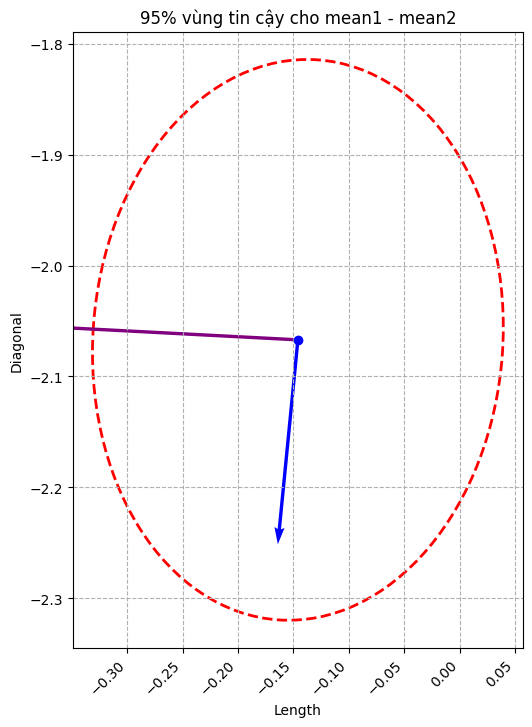

In [55]:
plt.figure(figsize=(8, 8))
ax = plt.gca()

# Vẽ elip confidence
confidence_ellipse = patches.Ellipse(
    xy=mean_diff,
    width=width,
    height=height,
    angle=angle_deg,
    edgecolor='red',
    facecolor='none',
    linewidth=2,
    linestyle='--'
)

# Thêm elip vào biểu đồ
ax.add_patch(confidence_ellipse)

# Vẽ vecto chính của elip
ax.quiver(mean_diff[0], mean_diff[1],
          eigenvectors[0, 0] * width / 2,
          eigenvectors[0, 1] * height / 2,
          angles='xy', scale_units='xy', scale=1, color='blue', label='e1')

ax.quiver(mean_diff[0], mean_diff[1],
          eigenvectors[1, 0] * width / 2,
          eigenvectors[1, 1] * height / 2,
          angles='xy', scale_units='xy', scale=1, color='purple', label='e2')

# Cài đặt cho trục
ax.set_aspect('equal', adjustable='box')
ax.autoscale_view()

plt.xlabel(variable1)
plt.ylabel(variable2)
plt.title(f'95% vùng tin cậy cho mean1 - mean2')
plt.grid(True, linestyle='--')

plt.xticks(rotation=45, ha='right')
ax.plot(mean_diff[0], mean_diff[1], 'bo')

plt.show()


* Rõ ràng, mean1 - mean2 = 0 không nằm trong vùng elip, ta có thể kết luận rằng 2 loại tiền là khác nhau, tại chiều dài có thể tương đương nhưng đường chéo lại khác nhau rõ rệt